### XML to dataframe

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

tree = ET.parse(r"D:\edalab\XML_Project\customers_orders.xml")
root = tree.getroot()

In [10]:
data = []

for customer in root.findall('Customer'):
    customer_id = customer.find('CustomerID').text
    name = customer.find('Name').text

    orders = customer.find('Orders')

    for order in orders.findall('Order'):
        order_id = order.find('OrderID').text

        items = order.find('Items')

        for item in items.findall('Item'):
            product_id = item.find('ProductID').text
            product_name = item.find('ProductName').text
            price = float(item.find('Price').text)
            quantity = int(item.find('Quantity').text)

            revenue = price * quantity

            data.append([
                customer_id,
                name,
                order_id,
                product_id,
                product_name,
                price,
                quantity,
                revenue
            ])

In [11]:
df = pd.DataFrame(data, columns=[
    "CustomerID", "Name", "OrderID",
    "ProductID", "ProductName",
    "Price", "Quantity", "Revenue"
])

df

,CustomerID,Name,OrderID,ProductID,ProductName,Price,Quantity,Revenue
0,001,John Doe,1001,P001,Laptop,1200.0,1,1200.0
1,001,John Doe,1001,P002,Mouse,25.0,2,50.0
2,001,John Doe,1002,P003,Monitor,300.0,1,300.0
3,002,Jane Smith,1003,P004,Tablet,500.0,1,500.0


### Total Revenue per Customer

In [12]:
customer_revenue = df.groupby("Name")["Revenue"].sum().reset_index()

customer_revenue

,Name,Revenue
0,Jane Smith,500.0
1,John Doe,1550.0


### Top Products by Revenue

In [14]:
product_revenue = df.groupby("ProductName")["Revenue"].sum().reset_index()

top_products = product_revenue.sort_values(by="Revenue", ascending=False)

top_products

,ProductName,Revenue
0,Laptop,1200.0
3,Tablet,500.0
1,Monitor,300.0
2,Mouse,50.0


### Visualization (Top 3 Products)

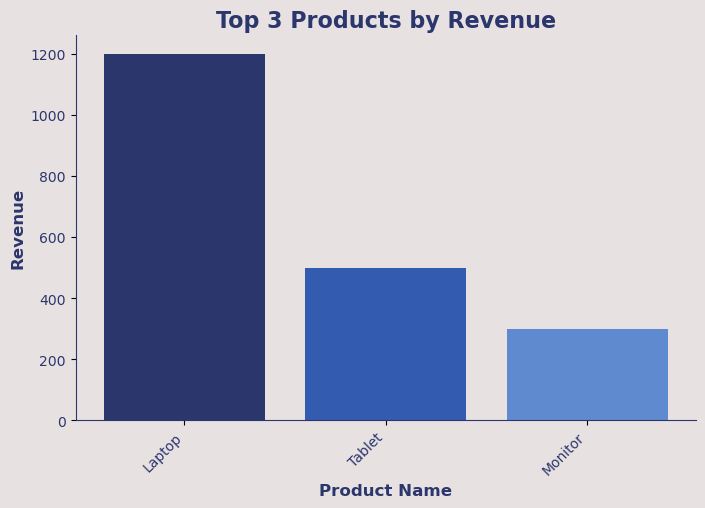

In [32]:
top3 = top_products.head(3)

colors = ["#2B366D", "#335CB0", "#5F8ACF"]  

plt.figure(figsize=(8,5), facecolor="#E8E1E1")
plt.bar(top3["ProductName"], top3["Revenue"], color=colors )

plt.title("Top 3 Products by Revenue" , fontsize=16, fontweight='bold', color="#2B366D")
plt.gca().set_facecolor("#E8E1E1")
plt.xlabel("Product Name", fontsize=12, fontweight='bold', color="#2B366D")
plt.ylabel("Revenue", fontsize=12, fontweight='bold', color="#2B366D")
plt.xticks(rotation=45, ha='right', fontsize=10, color="#2B366D")
plt.yticks(fontsize=10, color="#2B366D")
ax = plt.gca()
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color("#2B366D")
ax.spines['bottom'].set_color("#2B366D")
plt.show()